# setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/My Drive/NetsTeam6



import tensorflow as tf
from tensorflow import keras
from keras import models, layers, optimizers, Input
from keras.models import Sequential
from keras.layers import *
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.optimizers import Adam
from keras.datasets import mnist
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1ZnruOmr4taNKox9lB4Icg5MGMp0xxrOj/NetsTeam6


#data prep

In [ ]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

#making it more readable for the network
X_train = X_train.reshape(60000, 784).astype('float32') /255
X_test = X_test.reshape(10000, 784).astype('float32') /255

# one version stays flat for the tnn
TNN_Xtrain = X_train
TNN_Xtest = X_test

#one version gets square-ified for the cnn
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

# each item is a list of the outputs, each representing a digit 0-9
Y_train = to_categorical(Y_train, 10)
Y_original = Y_test # saving this for the confusion matrix later
Y_test = to_categorical(Y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# TNN

In [ ]:
TNNmodel = Sequential()

TNNmodel.add(Dense(100, input_dim=784, activation='sigmoid'))
TNNmodel.add(Dense(10,activation='softmax'))


TNNmodel.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
TNNhist = TNNmodel.fit(TNN_Xtrain, Y_train, validation_data=(TNN_Xtest, Y_test), batch_size=500, epochs=20,verbose=0,shuffle=True)
# TNNmodel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 0 final train Accuracy: 0.9711
Model 0 final validation Accuracy: 0.9654


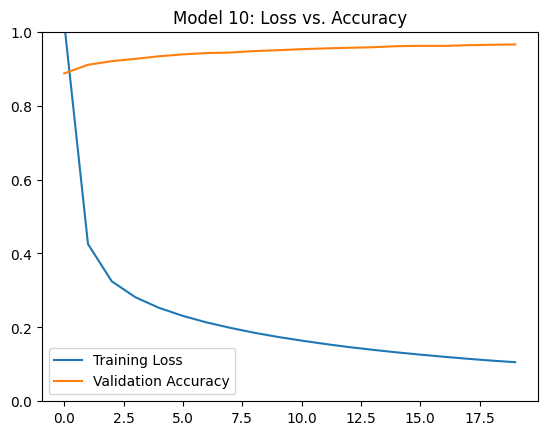

In [ ]:
print(f"Model 0 final train Accuracy: {TNNhist.history['accuracy'][-1]:.4f}")
print(f"Model 0 final validation Accuracy: {TNNhist.history['val_accuracy'][-1]:.4f}")

plt.plot(TNNhist.history['loss'], label='Training Loss')
plt.plot(TNNhist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 10: Loss vs. Accuracy')
plt.legend()
plt.ylim(0,1)
plt.show()

# CNN1: same as book


In [ ]:
model = Sequential()

# convolution
model.add(Conv2D(20,kernel_size=(5,5),activation='sigmoid',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

# classification and output
model.add(Dense(100,activation='sigmoid'))
model.add(Dense(10,activation='softmax'))

# run it
model.compile(loss='categorical_crossentropy', optimizer='rmsprop',metrics=['accuracy'])
hist = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), batch_size=500, epochs=20,verbose=0,shuffle=True)

# model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
print(f"Model 1 final Accuracy: {hist.history['accuracy'][-1]:.4f}")
print(f"Model 1 final validation Accuracy: {hist.history['val_accuracy'][-1]:.4f}")

plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Loss vs. Accuracy')
plt.legend()
plt.ylim(0,1)
plt.show()

# CNN2
added:
- padding
- relu on both convolution and classification
- more feature maps
- additional classification layer
- dropout on classification layers
- fewer nodes in each classif. layer

In [ ]:
model2 = Sequential()
# convolution
model2.add(Conv2D(32,kernel_size=(5,5),padding="same",activation='relu',input_shape=(28,28,1)))
model2.add(MaxPooling2D(pool_size=(2,2)))
model2.add(Flatten())
# classification
model2.add(Dense(32,activation='relu'))
model2.add(Dropout(0.25))
model2.add(Dense(32,activation='relu'))
model2.add(Dropout(0.25))
#output
model2.add(Dense(10,activation='softmax'))

# run it 😎
model2.compile(loss='categorical_crossentropy', optimizer='rmsprop',metrics=['accuracy'])
hist = model2.fit(X_train, Y_train, validation_data=(X_test, Y_test), batch_size=500, epochs=20,verbose=2,shuffle=True)

# model.summary()

Epoch 1/20
120/120 - 13s - 110ms/step - accuracy: 0.6581 - loss: 1.0266 - val_accuracy: 0.9217 - val_loss: 0.2944
Epoch 2/20
120/120 - 12s - 104ms/step - accuracy: 0.8567 - loss: 0.4541 - val_accuracy: 0.9603 - val_loss: 0.1418
Epoch 3/20
120/120 - 12s - 104ms/step - accuracy: 0.9149 - loss: 0.2851 - val_accuracy: 0.9729 - val_loss: 0.0899
Epoch 4/20
120/120 - 12s - 103ms/step - accuracy: 0.9385 - loss: 0.2087 - val_accuracy: 0.9777 - val_loss: 0.0719
Epoch 5/20
120/120 - 13s - 105ms/step - accuracy: 0.9520 - loss: 0.1671 - val_accuracy: 0.9800 - val_loss: 0.0646
Epoch 6/20
120/120 - 12s - 103ms/step - accuracy: 0.9585 - loss: 0.1411 - val_accuracy: 0.9822 - val_loss: 0.0577
Epoch 7/20
120/120 - 13s - 104ms/step - accuracy: 0.9640 - loss: 0.1258 - val_accuracy: 0.9832 - val_loss: 0.0546
Epoch 8/20
120/120 - 12s - 103ms/step - accuracy: 0.9679 - loss: 0.1121 - val_accuracy: 0.9866 - val_loss: 0.0439
Epoch 9/20
120/120 - 12s - 103ms/step - accuracy: 0.9700 - loss: 0.1035 - val_accuracy: 

In [ ]:
print(f"Model 2 final Accuracy: {hist.history['accuracy'][-1]:.4f}")
print(f"Model 2 final validation Accuracy: {hist.history['val_accuracy'][-1]:.4f}")

plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2: Loss vs. Accuracy')
plt.legend()
plt.ylim(0,1)
plt.show()

# confusion matrices

In [ ]:
# MATRIX FOR TNN======================================================================================================
predictions_TNN = TNNmodel.predict(TNN_Xtest)

#convert the raw probabilities into a class integer so that the conf. matrix can compare them
predicted_classes_TNN = np.argmax(predictions_TNN, axis=1)

#use the Y_original because that's the class integers instead of one-hots
disp_TNN = ConfusionMatrixDisplay.from_predictions(Y_original, predicted_classes_TNN)
disp_TNN.figure_.suptitle("confusion for TNN")


# SAME DEAL BUT FOR CNN 1 ===============================================================================================
predictions_1 = model.predict(X_test)
predicted_classes_1 = np.argmax(predictions_1, axis=1)
disp_1 = ConfusionMatrixDisplay.from_predictions(Y_original, predicted_classes_1)
disp_1.figure_.suptitle("confusion for CNN 1")


# SAME DEAL BUT FOR CNN 1 ===============================================================================================
predictions_2 = model2.predict(X_test)

predicted_classes_2 = np.argmax(predictions_2, axis=1)

disp_2 = ConfusionMatrixDisplay.from_predictions(Y_original, predicted_classes_2)
disp_2.figure_.suptitle("confusion for CNN 2")


# dicussion

we ran each for 20 epochs with 500 batch size for each model
final test accuracies:
- TNN - .965
- CNN1 - .975
- CNN2 - .988

TNN hit highish accuracy faster than CNN1 did, but didnt get much higher after that and topped out lower
CNN1 had a really rocky start but got good results by the end
CNN2 started high, and seems to have reached numbers by epoch 4 that took the other models 12+ epochs to reach; in addition to a better final accuracy at 20. so, better in every way

results are basically what we expected -- we knew from class that convolution would do better than TNN for images, and we saw in the book that RELU (cnn2) should get much faster learning than sigmoid (cnn1)

there were several potential improvements that the chapter suggested and no cohesive "mark 2" version, so we just picked sever and mashed them together, with a little trial and error to find options that worked well.